In [1]:
# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import search
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

In [2]:
# Bounding box for Little Desert NP, Queensland, Australia: left=141.32, bottom=-34.97, right=141.52, top=-34.77
lon_min = 141.32
lon_max = 141.52 
lat_min = -34.97
lat_max = -34.77

bbox = (lon_min, lat_min, lon_max, lat_max)

In [3]:
GeoJSON(shapely.geometry.box(*bbox).__geo_interface__)

<IPython.display.GeoJSON object>

In [4]:
# import cartopy.crs as ccrs
# import matplotlib.pyplot as plt

# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.stock_img()


# plt.scatter([lon_min, lon_max], [lat_min, lat_max],
#          color='blue', linewidth=2, marker='o',
#          transform=ccrs.Geodetic(),
#          )
# plt.xlim(lon_min - 50, lon_max + 50)
# plt.ylim(lat_min - 50, lat_max + 50)

# plt.show()

In [5]:
# import os
# os.environ['CDSAPI_RC'] = '/cmsaf/nfshome/lbeck/projects/ccitoolbox/training-ideas/.cdsapirc'
# import cdsapi

# # Now, cdsapi.Client() will look for the file at the specified path
# client = cdsapi.Client()

In [7]:
# import cdsapi

# dataset = "satellite-land-cover"
# request = {
#     "variable": "all",
#     "year": ["2016"],
#     "version": ["v2_1_1"],
#     "area": [-34.77, 141.32, -34.97, 141.52]
# }

# output_filename = 'downloaded_land_cover.nc'

# # Assuming the .cdsapirc issue is resolved, this will download the data
# # and then you can open it with xarray.

# # The .download() method returns None, or the path to the downloaded file in newer versions
# # We'll explicitly define the output filename.
# client.retrieve(dataset, request).download(output_filename)

# # Load the downloaded NetCDF file into an xarray Dataset
# lc_ds = xr.open_dataset(output_filename)

# # Display the dataset to see its structure and contents
# display(lc_ds)


In [10]:
# Open the ESA CCI zarr store
cci_zarr_store = new_data_store("esa-cci-zarr")
cci_store = new_data_store("esa-cci")

In [11]:
list_ecv_datasets("LC")

[('esacci.LC.13-yrs.L4.WB.ASAR.Envisat.Map.4-0.r1', 'esa-cci'),
 ('esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1', 'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A01.v1-2.Africa',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A01.v1-2.Africa',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A03.v1-2.Siberia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A02.v1-2.Amazonia',
  'esa-cci'),
 ('esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A01.v1-2.Africa',
  'esa-cci'),
 ('ESACC

In [12]:
# from xcube.core.store import new_data_store
# cci_zarr_store = new_data_store("esa-cci-zarr")
# lc_ds = cci_zarr_store.open_data(
#     'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'
# )
# subset_spatial_op = get_op('subset_spatial')
# lc_sub = subset_spatial_op(ds=lc_ds, region=bbox)
# data_id = 'esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1'
data_id = 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'

cci_zarr_store.describe_data(data_id)

In [13]:
# variables = ['lccs_class']  # Variable to retrieve
# land_cover_ds = cci_store.open_data(
#     data_id=data_id,
#     variable_names=variables,
#     bbox=bbox  # Uncomment if regional selection is needed
# )

In [14]:
# Land Cover data ID
data_id = 'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr' 

land_cover_ds = cci_zarr_store.open_data(
    data_id = data_id
)
# Building the subset 
subset_spatial_op = get_op('subset_spatial')
lc_sub = subset_spatial_op(ds=land_cover_ds, region=bbox)

# The data from CCI Toolbox is Level 4, for the categorisation by Lucas et al., we need Level 3 data -> transform it back?
Question: Method valid?

In [15]:
# from L4 to L3
lc_l4 = lc_sub['lccs_class']  
lc_l3 = (lc_l4 // 10) * 10


lc_l3.name = 'lccs_class_level3'
lc_sub['lccs_class_level3'] = lc_l3.astype(np.float32)
lc_sub

<xarray.Dataset> Size: 3MB
Dimensions:              (time: 24, lat: 73, lon: 73)
Coordinates:
  * lat                  (lat) float32 292B -34.77 -34.77 ... -34.97 -34.97
  * lon                  (lon) float32 292B 141.3 141.3 141.3 ... 141.5 141.5
  * time                 (time) datetime64[ns] 192B 1992-07-02 ... 2015-07-03
Data variables:
    change_count         (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
    current_pixel_state  (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
    lccs_class_level3    (time, lat, lon) float32 512kB dask.array<chunksize=(1, 73, 73), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                CF-1.6
    TileSize:                   2048:2048
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/b382ebe6679...
    cdm_data_type:              grid
    comment:                    
    contact:                    landcover-cci@uclouvain.be
    ...                         ...
    time_coverage_start:        20150703T000000Z
    title:                      ESA CCI Land Cover Map
    tracking_id:                12590bad-9014-4a91-9048-d06b67965490
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((141.31944274902344 -34.9722213745117...

In [16]:
lc_sub.lccs_class_level3.values

array([[[120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        ...,
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [ 60.,  60.,  60., ..., 120., 120., 120.]],

       [[120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        ...,
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [ 60.,  60.,  60., ..., 120., 120., 120.]],

       [[120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        ...,
        [120., 120., 120., ..., 120., 120., 120.],
        [120., 120., 120., ..., 120., 120., 120.],
        [ 60.,  60.,  60., ..., 120., 120., 120.]],

       ...,

       [[120., 120., 120

In [66]:

# Define the LCCS colours according to their ID and names
class_ids = [
    10, 11, 12, 20, 30, 40,           # Cultivated areas
    50, 60, 61, 62,                  # Broadleaved trees
    70, 71, 72,                      # Needleleaved evergreen trees
    80, 81, 82,                      # Needleleaved deciduous trees
    90, 100, 110,                    # Mixed vegetation
    120, 121, 122,                   # Shrubland
    130, 140,                        # Herbaceous and lichens/mosses
    150, 151, 152, 153,              # Sparse vegetation
    160, 170, 180,                   # Aquatic vegetation
    190,                             # Artificial surfaces
    200, 201, 202,                   # Bare areas
    210, 220                         # Water bodies, snow and ice
]

class_names = [
    "Rainfed crops",                                   # 10
    "Rainfed herbaceous crops",                        # 11
    "Rainfed shrub/tree crops",                        # 12
    "Irrigated crops",                                 # 20
    "Cropland/Natural vegetation mosaic",              # 30
    "Natural vegetation/Cropland mosaic",              # 40
    "Broadleaved evergreen/semi-deciduous trees",      # 50
    "Broadleaved deciduous trees",                     # 60
    "Broadleaved deciduous closed trees",              # 61
    "Broadleaved deciduous open trees",                # 62
    "Needleleaved evergreen trees",                    # 70
    "Needleleaved evergreen closed trees",             # 71
    "Needleleaved evergreen open trees",               # 72
    "Needleleaved deciduous trees",                    # 80
    "Needleleaved deciduous closed trees",             # 81
    "Needleleaved deciduous open trees",               # 82
    "Mixed broadleaved/needleleaved trees",            # 90
    "Mixed trees/shrubland/herbaceous",                # 100
    "Herbaceous/trees/shrubland",                      # 110
    "Shrubland",                                       # 120
    "Evergreen shrubland",                             # 121
    "Deciduous shrubland",                             # 122
    "Grassland",                                       # 130
    "Lichens and mosses",                              # 140
    "Sparse vegetation",                               # 150
    "Sparse trees",                                    # 151
    "Sparse shrubs",                                   # 152
    "Sparse herbaceous",                               # 153
    "Flooded trees (fresh water)",                     # 160
    "Flooded trees (saline/brackish water)",           # 170
    "Flooded shrubs/herbaceous",                       # 180
    "Urban areas",                                     # 190
    "Bare areas",                                      # 200
    "Consolidated bare areas",                         # 201
    "Unconsolidated bare areas",                       # 202
    "Water bodies",                                    # 210
    "Snow and ice"                                     # 220
]

colors = [
    "#ffff64",  # 10: Cropland, rainfed (official)
    "#ffff64",  # 11: Herbaceous cover (same as parent 10)
    "#ffff64",  # 12: Tree or shrub cover (same as parent 10)
    "#aaf0f0",  # 20: Cropland, irrigated (official)
    "#dcf064",  # 30: Mosaic cropland >50% (official)
    "#c8c864",  # 40: Mosaic natural vegetation >50% (official)
    "#006400",  # 50: Tree broadleaved evergreen (official)
    "#00a000",  # 60: Tree broadleaved deciduous (official)
    "#00a000",  # 61: Tree broadleaved deciduous closed (same as parent 60)
    "#00a000",  # 62: Tree broadleaved deciduous open (same as parent 60)
    "#003c00",  # 70: Tree needleleaved evergreen (official)
    "#003c00",  # 71: Tree needleleaved evergreen closed (same as parent 70)
    "#003c00",  # 72: Tree needleleaved evergreen open (same as parent 70)
    "#285000",  # 80: Tree needleleaved deciduous (official)
    "#285000",  # 81: Tree needleleaved deciduous closed (same as parent 80)
    "#285000",  # 82: Tree needleleaved deciduous open (same as parent 80)
    "#788200",  # 90: Tree cover, mixed leaf type (official)
    "#8ca000",  # 100: Mosaic tree/shrub >50% (official)
    "#be9600",  # 110: Mosaic herbaceous >50% (official)
    "#966400",  # 120: Shrubland (official)
    "#966400",  # 121: Evergreen shrubland (same as parent 120)
    "#966400",  # 122: Deciduous shrubland (same as parent 120)
    "#ffb432",  # 130: Grassland (official)
    "#ffdcd2",  # 140: Lichens and mosses (official)
    "#ffebaf",  # 150: Sparse vegetation (official)
    "#ffebaf",  # 151: Sparse tree (same as parent 150)
    "#ffebaf",  # 152: Sparse shrub (same as parent 150)
    "#ffebaf",  # 153: Sparse herbaceous (same as parent 150)
    "#00785a",  # 160: Tree flooded fresh/brackish (official)
    "#009678",  # 170: Tree flooded saline (official)
    "#00dc82",  # 180: Shrub/herbaceous flooded (official)
    "#c31400",  # 190: Urban areas (official)
    "#fff5d7",  # 200: Bare areas (official)
    "#fff5d7",  # 201: Consolidated bare (same as parent 200)
    "#fff5d7",  # 202: Unconsolidated bare (same as parent 200)
    "#0046c8",  # 210: Water bodies (official - BLUE!)
    "#ffffff"   # 220: Permanent snow and ice (official)
]
cmap_lc = ListedColormap(colors)


Processing year 2014...


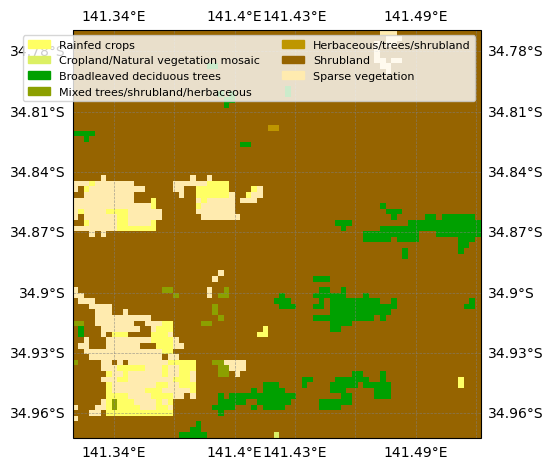

Processing year 2015...


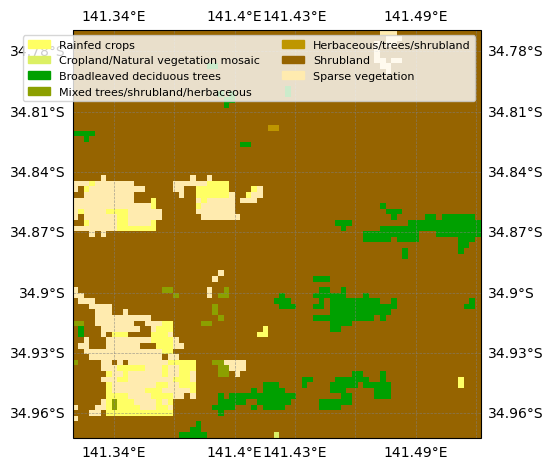

In [18]:
# Define years to loop through
years = range(2014, 2016)  # adapt as needed
# cmap = ListedColormap(colors)
# ensure that the colour map s used correctly
norm = BoundaryNorm(class_ids + [max(class_ids)+1], ncolors=cmap_lc.N)

for year in years:
    print(f"Processing year {year}...")
    
    # Create timestep for biomass (yearly data)
    timestep = f'{year}-01-01'
    
    # Load and extract the biomass data
    lc = lc_sub["lccs_class_level3"].sel(time=timestep, method='nearest').compute()
    time_str = lc_sub['time'].sel(time=timestep, method='nearest').dt.strftime('%Y').item()
    lat = lc_sub["lat"]
    lon = lc_sub["lon"]
    
    fig = plt.figure()
    
    # Create two axes with the same projection
    ax = plt.axes(projection=ccrs.PlateCarree())
  
    # Plot lc on first axis
    mesh_biomass = ax.pcolormesh(
        lon, lat, lc,
        cmap=cmap_lc, shading="auto",
        norm=norm
    )
    
    # Add lat/lon gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")
    
    # Add custom legend
    from matplotlib.patches import Patch
    # Find the unique land cover classes in the current plotted area to reduce the legend entries
    visible_classes = np.unique(lc.values)

    # Build legend only for classes present in the plot
    legend_handles = [
        Patch(color=colors[class_ids.index(cid)], label=class_names[class_ids.index(cid)])
        for cid in visible_classes if cid in class_ids
    ]
    
    ax.legend(handles=legend_handles, bbox_to_anchor=(1, 1), loc="upper right", ncol=2,fontsize=8)
    plt.show()

Note: These look very different to the LC plots by Richard, same bounding box - see below - is it only due to the resolution?

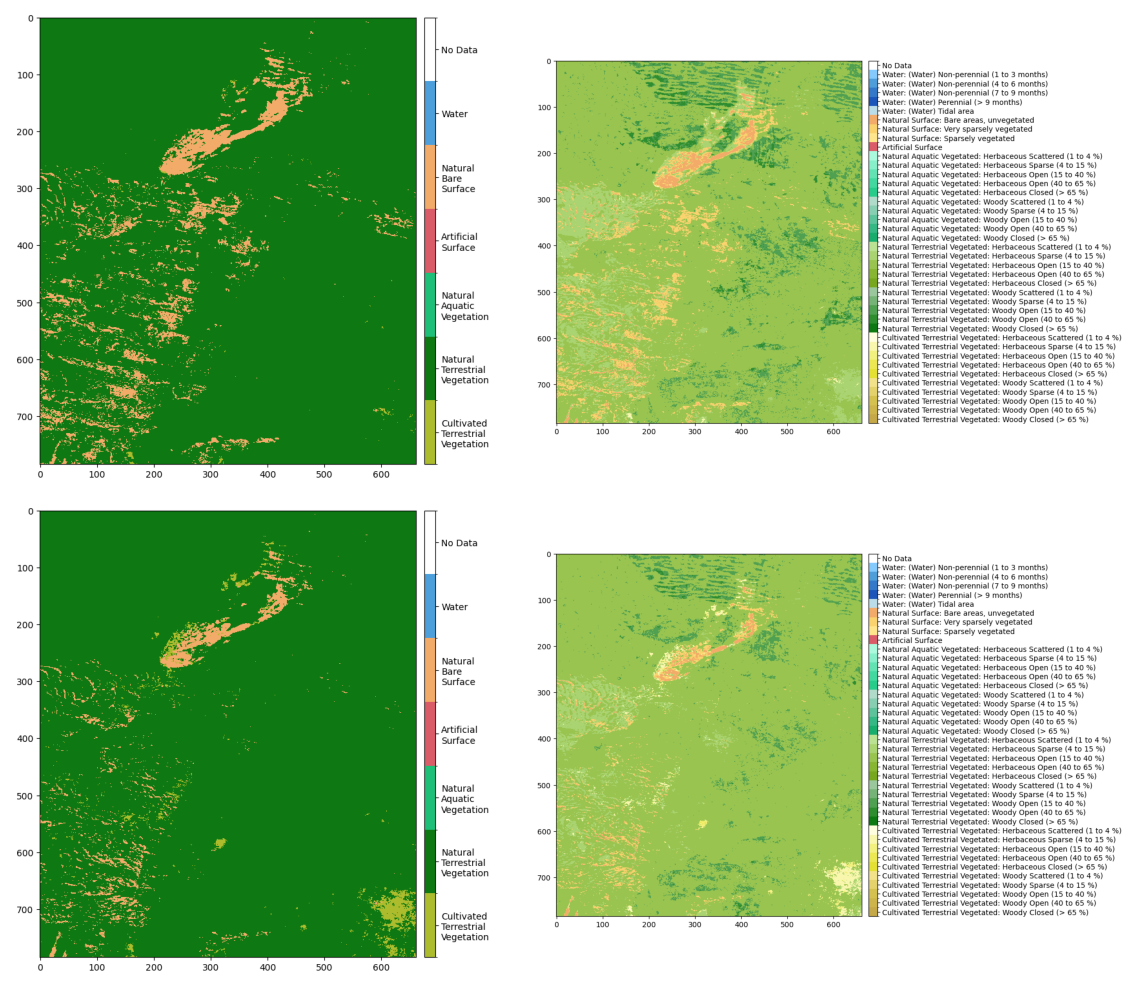

In [19]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_sub["lccs_class_level3"].sel(time='2014-01-01', method='nearest').astype(np.float32)
end = lc_sub["lccs_class_level3"].sel(time='2015-01-01', method='nearest').astype(np.float32)
ignore_no_change = True
change_vals = (start * 1000) + end

if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(change_vals)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [20]:
np.unique(change_vals)

array([0.], dtype=float32)

# ~~Test for Iberian Peninsula~~ -> overwriting it for a quick check for desert in AUS
Reduced the bbox to west part, more change to see there

In [64]:
# # Set bounding box by defining the longitude minimum, latitude minimum, longitude maximum and latitude maximum
# bbox_iberianpeninsula = (-10.6, 36.0, 4.15, 44.0) # Iberian Peninsula

# bbox_west = (-8.8, 39.0, -7.5, 43.0) # West part of Ib. Pen. 
# # Display bounding box for reference
# GeoJSON(shapely.geometry.box(*bbox_west).__geo_interface__)

# OVERWRITING HERE: 

In [22]:
# lc_ip = subset_spatial_op(ds=land_cover_ds, region=bbox_west)
lc_ip = lc_sub

In [23]:
# from L4 to L3
lc_l4 = lc_ip['lccs_class']  
lc_l3 = (lc_l4 // 10) * 10


lc_l3.name = 'lccs_class_level3'
lc_ip['lccs_class_level3'] = lc_l3.astype(np.float32)


In [24]:
lc_ip['lccs_class_level3'].sel(time=timestep, method='nearest').values

array([[120., 120., 120., ..., 120., 120., 120.],
       [120., 120., 120., ..., 120., 120., 120.],
       [120., 120., 120., ..., 120., 120., 120.],
       ...,
       [120., 120., 120., ..., 120., 120., 120.],
       [120., 120., 120., ..., 120., 120., 120.],
       [120., 120., 120., ..., 120., 120., 120.]], dtype=float32)

Processing year 2015...


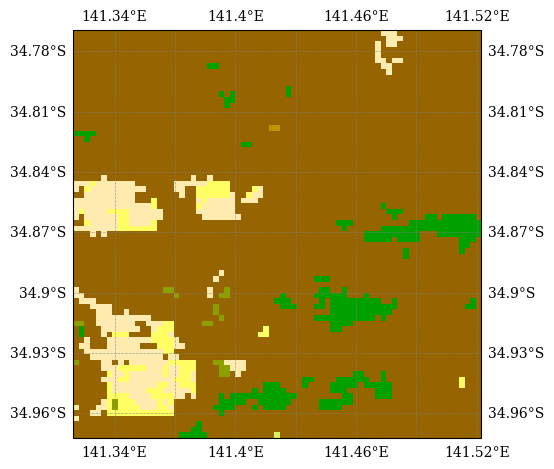

In [67]:
# Define years to loop through
years = range(2015, 2016)  # adapt as needed
cmap = ListedColormap(colors)
# ensure that the colour map s used correctly
norm = BoundaryNorm(class_ids + [max(class_ids)+1], ncolors=cmap.N)

for year in years:
    print(f"Processing year {year}...")
    
    # Create timestep for biomass (yearly data)
    timestep = f'{year}-01-01'
    
    # Load and extract the biomass data
    lc = lc_ip["lccs_class_level3"].sel(time=timestep, method='nearest').compute()
    time_str = lc_ip['time'].sel(time=timestep, method='nearest').dt.strftime('%Y').item()
    lat = lc_ip["lat"]
    lon = lc_ip["lon"]
    
    fig = plt.figure()
    
    # Create two axes with the same projection
    ax = plt.axes(projection=ccrs.PlateCarree())
  
    # Plot lc on first axis
    mesh_biomass = ax.pcolormesh(
        lon, lat, lc,
        cmap=cmap, shading="auto",
        norm=norm
    )
    
    # Add lat/lon gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")
    
    # Add custom legend
    from matplotlib.patches import Patch
    # Find the unique land cover classes in the current plotted area to reduce the legend entries
    visible_classes = np.unique(lc.values)

    # Build legend only for classes present in the plot
    legend_handles = [
        Patch(color=colors[class_ids.index(cid)], label=class_names[class_ids.index(cid)])
        for cid in visible_classes if cid in class_ids
    ]
    
    #ax.legend(handles=legend_handles, bbox_to_anchor=(1, 1), loc="upper right", ncol=1,fontsize=8)
    plt.show()

# Level 3 Change Maps
## GAINS
# Note: had to enlarge the time span to see anything at all. Using 2000 - 2015 for now

In [80]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').astype(np.float32)
end = lc_ip["lccs_class_level3"].sel(time='2015-01-01', method='nearest').astype(np.float32)
ignore_no_change = True
change_vals = (start * 1000) + end

if ignore_no_change:
    change_vals= np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([     0.,  60120., 120010., 120060., 120100., 120150., 150100.],
      dtype=float32)

In [83]:
level3 = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').drop_vars("time")
# Create a new Xarray.DataArray
obs_gain_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=level3.coords,
    dims=level3.dims,
    name="observed change",
    attrs=level3.attrs,
    fastpath=False,
)

In [84]:
obs_gain_l3 = obs_gain_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_gain_l3_T1T2

In [85]:
obs_gain_l3.l3_T1T2
unique_vals = np.unique(obs_gain_l3.l3_T1T2.values)

print(unique_vals)

[     0.  60120. 120010. 120060. 120100. 120150. 150100.]


In [86]:
# Define a colour scheme for the Level 3
LEVEL3_GAINSLOSSES = {
    0: (255, 255, 255, 255, "No Change"),
    111112: (14, 121, 18, 255, " "),
    111123: (123, 243, 236, 255, " "),
    111124: (30, 191, 121, 255, " "),
    111215: (218, 92, 105, 255, " "),
    111216: (243, 171, 105, 255, " "),
    111220: (26, 84, 185, 255, " "),
    112111: (172, 188, 45, 255, " "),
    112123: (123, 243, 236, 255, " "),
    112124: (30, 191, 121, 255, " "),
    112215: (218, 92, 105, 255, " "),
    112216: (243, 171, 105, 255, " "),
    112220: (26, 84, 185, 255, " "),
    124111: (172, 188, 45, 255, " "),
    124112: (14, 121, 18, 255, " "),
    124123: (123, 243, 236, 255, " "),
    124215: (218, 92, 105, 255, " "),
    124216: (243, 171, 105, 255, " "),
    124220: (26, 84, 185, 255, " "),
    215111: (172, 188, 45, 255, " "),
    215112: (14, 121, 18, 255, " "),
    215123: (123, 243, 236, 255, " "),
    215124: (30, 191, 121, 255, " "),
    215216: (243, 171, 105, 255, " "),
    215220: (26, 84, 185, 255, " "),
    216111: (172, 188, 45, 255, " "),
    216112: (14, 121, 18, 255, " "),
    216123: (123, 243, 236, 255, " "),
    216124: (30, 191, 121, 255, " "),
    216215: (218, 92, 105, 255, " "),
    216220: (26, 84, 185, 255, " "),
    220111: (172, 188, 45, 255, " "),
    220112: (14, 121, 18, 255, " "),
    220123: (123, 243, 236, 255, " "),
    220124: (30, 191, 121, 255, " "),
    220215: (218, 92, 105, 255, " "),
    220216: (243, 171, 105, 255, " ")}

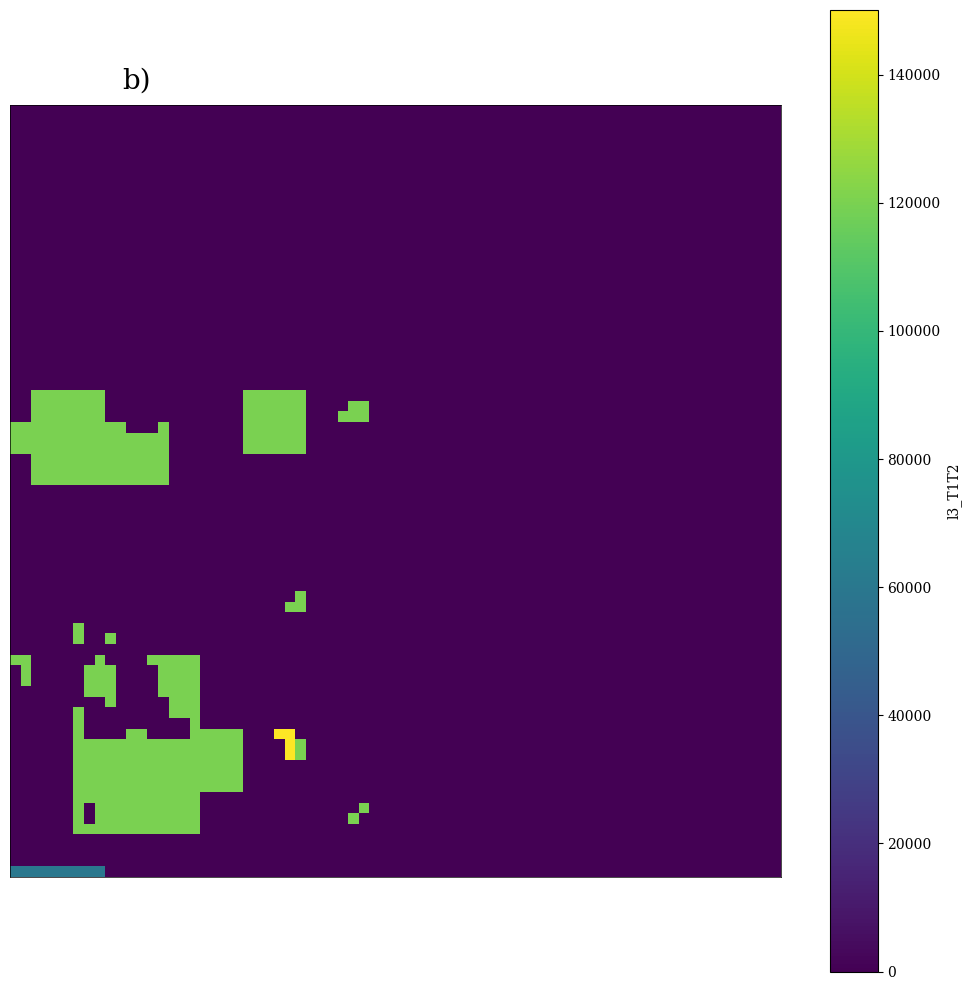

In [87]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rioxarray  # make sure rioxarray is installed

# Extract codes and colors
codes = list(LEVEL3_GAINSLOSSES.keys())
rgba_colors = [(r/255, g/255, b/255, a/255) for (r, g, b, a, _) in LEVEL3_GAINSLOSSES.values()]

# Make a ListedColormap
cmap = mcolors.ListedColormap(rgba_colors, name='Level3')

# Make boundaries centered on your codes
codes_sorted = sorted(codes)
bounds = [c - 0.5 for c in codes_sorted] + [codes_sorted[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_gain_l3 = obs_gain_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_gain_l3.l3_T1T2.plot(
    ax=ax,
    #cmap=cmap,
    #norm=norm,
    add_colorbar=True
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "b)",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

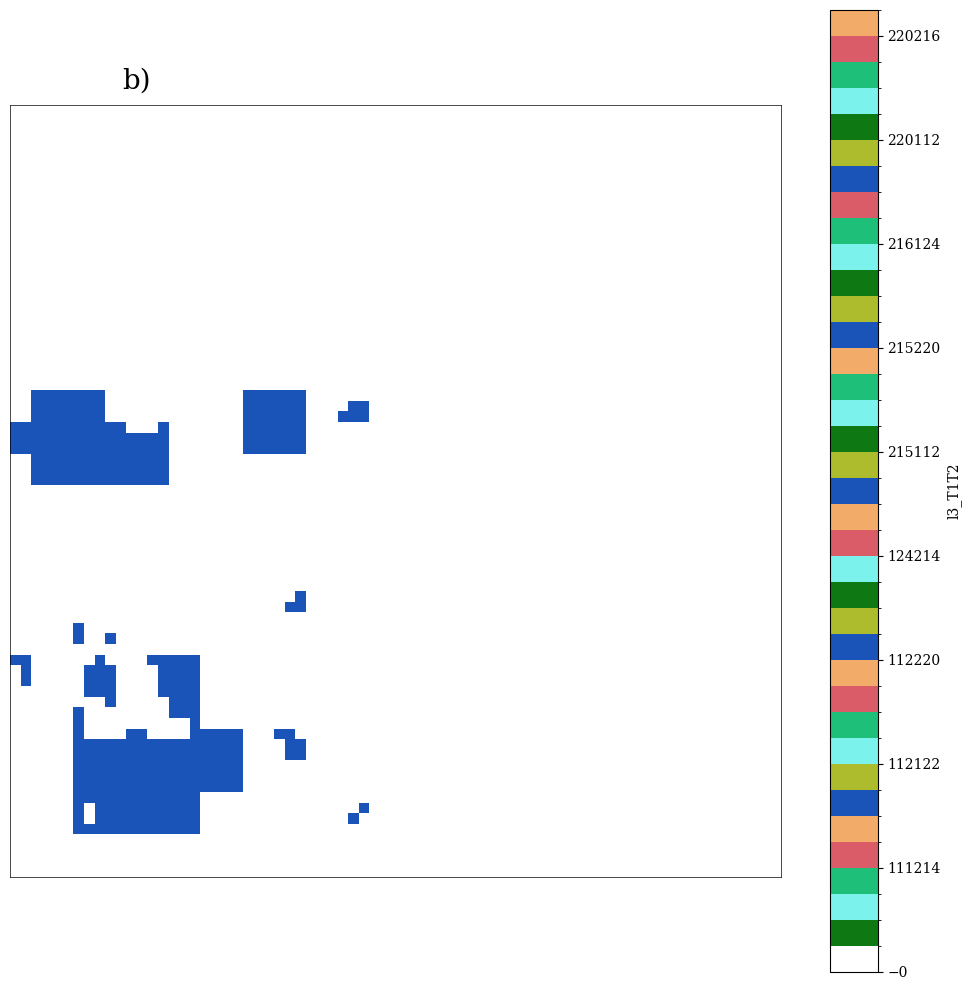

In [88]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rioxarray  # make sure rioxarray is installed

# Extract codes and colors
codes = list(LEVEL3_GAINSLOSSES.keys())
rgba_colors = [(r/255, g/255, b/255, a/255) for (r, g, b, a, _) in LEVEL3_GAINSLOSSES.values()]

# Make a ListedColormap
cmap = mcolors.ListedColormap(rgba_colors, name='Level3')

# Make boundaries centered on your codes
codes_sorted = sorted(codes)
bounds = [c - 0.5 for c in codes_sorted] + [codes_sorted[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_gain_l3 = obs_gain_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_gain_l3.l3_T1T2.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=True
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "b)",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

## I don't understand the colorbar, as it is repetetive. Compared it with the one in RL's notebook and it is the same there. 

Comparing Level 3 vs Level 4 LC

In [34]:
lc4

<xarray.DataArray 'lccs_class' (lat: 73, lon: 73)> Size: 21kB
array([[122., 122., 122., ..., 122., 122., 122.],
       [122., 122., 122., ..., 122., 122., 122.],
       [122., 122., 122., ..., 122., 122., 122.],
       ...,
       [122., 120., 120., ..., 122., 120., 120.],
       [122., 122., 122., ..., 122., 122., 122.],
       [ 60.,  60.,  60., ..., 122., 122., 122.]], dtype=float32)
Coordinates:
  * lat      (lat) float32 292B -34.77 -34.77 -34.78 ... -34.97 -34.97 -34.97
  * lon      (lon) float32 292B 141.3 141.3 141.3 141.3 ... 141.5 141.5 141.5
    time     datetime64[ns] 8B 2002-07-03
Attributes:
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    valid_max:            220
    valid_min:            1

# Level 3 change map 
## LOSS

In [90]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
# (Note changing to (end * 1000) + start
start = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').astype(np.float32)
end = lc_ip["lccs_class_level3"].sel(time='2015-01-01', method='nearest').astype(np.float32)
ignore_no_change = True
change_vals = (end * 1000) + start
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
#level_3 = lc.level3[0].drop_vars("time")

In [91]:
np.unique(change_vals)

array([     0.,  10120.,  60120., 100120., 100150., 120060., 150120.],
      dtype=float32)

In [92]:
# Create a new Xarray.DataArray
level3 = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').drop_vars("time")

obs_loss_l3_T1T2= xr.DataArray(
    data=change_vals,
    coords=level3.coords,
    dims=level3.dims,
    name="observed losses",
    attrs=level3.attrs,
    fastpath=False,
)

In [93]:
obs_loss_l3 = obs_loss_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_loss_l3_T1T2

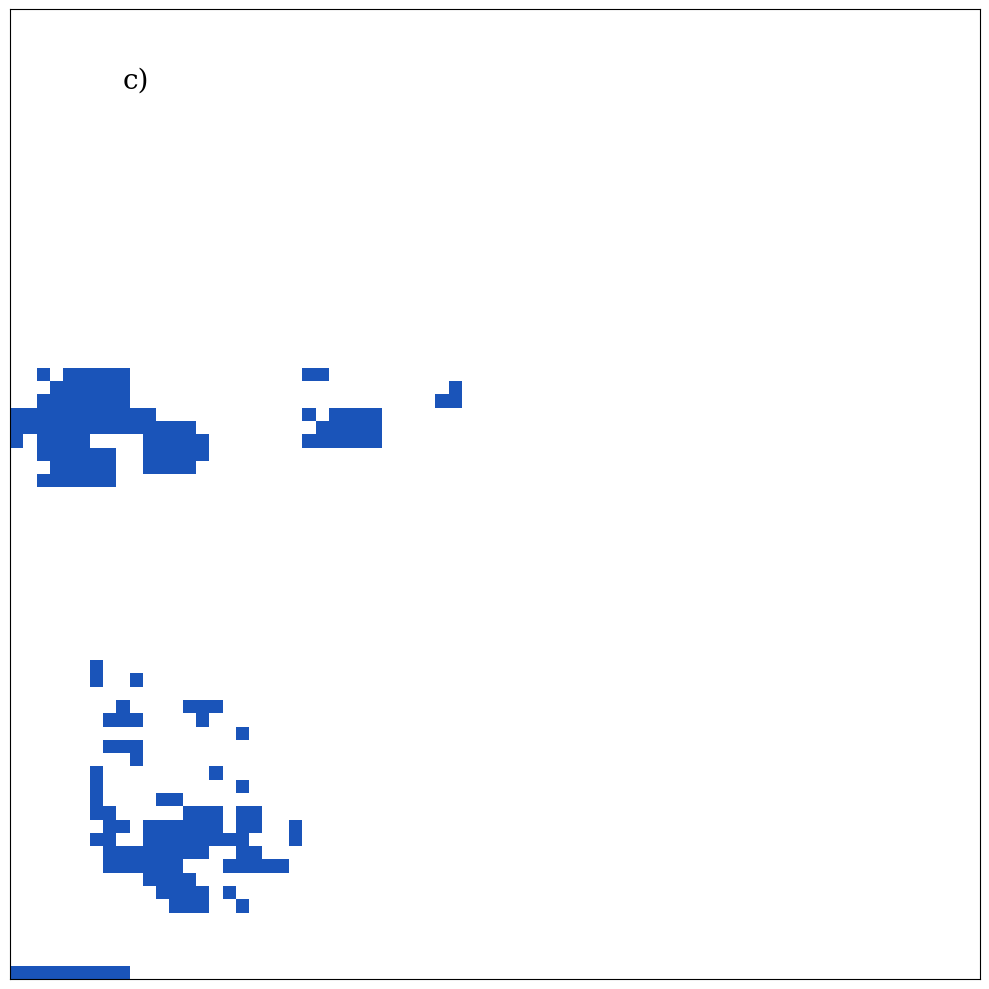

In [94]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rioxarray  # make sure rioxarray is installed


# -----------------------------
# Font settings
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times", "DejaVu Serif"]

# 1. Extract your codes and colors
codes = list(LEVEL3_GAINSLOSSES.keys())
rgba_colors = [(r/255, g/255, b/255, a/255) for (r, g, b, a, _) in LEVEL3_GAINSLOSSES.values()]

# 2. Make a ListedColormap
cmap = mcolors.ListedColormap(rgba_colors, name='Level3')

# 3. Make boundaries centered on your codes
codes_sorted = sorted(codes)
bounds = [c - 0.5 for c in codes_sorted] + [codes_sorted[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Ensure dataset has CRS but DO NOT reproject ---
obs_loss_l3 = obs_loss_l3.rio.write_crs("EPSG:3577")  # original Australian Albers

# 4. Plot using native EPSG:3577 coordinates with square aspect
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_loss_l3.l3_T1T2.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "c)",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add thin black border around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

# Title
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

# Areas with NO CHANGE

In [95]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').astype(np.float32)
end = lc_ip["lccs_class_level3"].sel(time='2015-01-01', method='nearest').astype(np.float32)
ignore_change = True
change_vals = (start * 1000) + end
if ignore_change:
    change_vals = np.where(start != end, 0, change_vals)

In [97]:
# Create a new Xarray.DataArray
level3 = lc_ip["lccs_class_level3"].sel(time='2000-01-01', method='nearest').drop_vars("time")

obs_no_change_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=level3.coords,
    dims=level3.dims,
    name="no change",
    attrs=level3.attrs,
    fastpath=False,
)

In [98]:
print(obs_no_change_l3_T1T2)

<xarray.DataArray 'no change' (lat: 73, lon: 73)> Size: 21kB
array([[120120., 120120., 120120., ..., 120120., 120120., 120120.],
       [120120., 120120., 120120., ..., 120120., 120120., 120120.],
       [120120., 120120., 120120., ..., 120120., 120120., 120120.],
       ...,
       [120120., 120120., 120120., ..., 120120., 120120., 120120.],
       [120120., 120120., 120120., ..., 120120., 120120., 120120.],
       [     0.,      0.,      0., ..., 120120., 120120., 120120.]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 292B -34.77 -34.77 -34.78 ... -34.97 -34.97 -34.97
  * lon      (lon) float32 292B 141.3 141.3 141.3 141.3 ... 141.5 141.5 141.5


In [99]:
obs_no_change_l3 = obs_no_change_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_no_change_l3_T1T2

In [100]:
obs_no_change_l3.l3_T1T2
unique_vals = np.unique(obs_no_change_l3.l3_T1T2.values)

print(unique_vals)

[     0.  10010.  30030.  60060. 100100. 110110. 120120. 150150.]


In [101]:
# Define a colour scheme for the Level 3 no change
LEVEL3_NOCHANGE = {
    0: (255, 255, 255, 255, "Change"),
    111111: (172, 188, 45, 255, " "),
    112112: (14, 121, 18, 255, " "),
    123123: (0, 255, 255, 255, " "),
    124124: (30, 191, 121, 255, " "),
    215215: (218, 92, 105, 255, " "),
    216216: (243, 171, 105, 255, " "),
    220220: (77, 159, 220, 255, " ")}

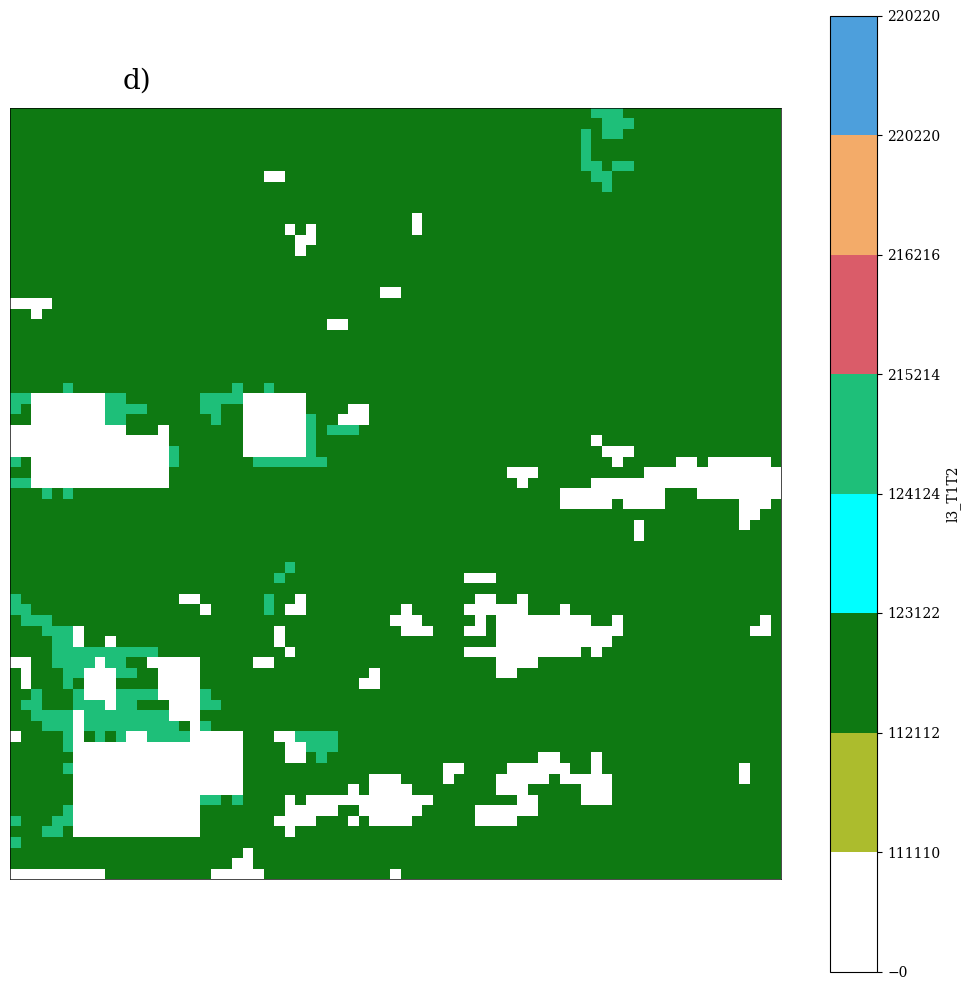

In [102]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rioxarray  # make sure rioxarray is installed

# Extract codes and colors
codes = list(LEVEL3_NOCHANGE.keys())
rgba_colors = [(r/255, g/255, b/255, a/255) for (r, g, b, a, _) in LEVEL3_NOCHANGE.values()]

# Make a ListedColormap
cmap = mcolors.ListedColormap(rgba_colors, name='Level3')

# Make boundaries centered on your codes
codes_sorted = sorted(codes)
bounds = [c - 0.5 for c in codes_sorted] + [codes_sorted[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Ensure dataset has CRS but DO NOT reproject ---
obs_no_change_l3 = obs_no_change_l3.rio.write_crs("EPSG:3577")

# Plot using native EPSG:3577 coordinates (square figure)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_no_change_l3.l3_T1T2.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=True
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "d)",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add thin black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title (currently blank to match your example)
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

In [103]:
unique_vals = np.unique(lc_ip.lccs_class.values)

print(unique_vals)

[ 10.  11.  30.  60.  62. 100. 110. 120. 122. 150.]


In [104]:
lifeform_map = {
    1: 0, 2: 1, 3: 2, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0,
    9: 1, 10: 1, 11: 1, 12: 1, 13: 1,
    14: 2, 15: 2, 16: 2, 17: 2, 18: 2,
    19: 0, 20: 1, 21: 2, 22: 2, 23: 0, 24: 0, 25: 0, 26: 0,
    27: 1, 28: 1, 29: 1, 30: 1, 31: 1,
    32: 2, 33: 2, 34: 2, 35: 2, 36: 2,
    37: 0, 38: 1, 39: 2, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0,
    45: 1, 46: 1, 47: 1, 48: 1, 49: 1,
    50: 2, 51: 2, 52: 2, 53: 2, 54: 2,
    55: 0, 56: 1, 57: 2, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0,
    63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1,
    69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1,
    75: 1, 76: 1, 77: 1,
    78: 2, 79: 2, 80: 2, 81: 2, 82: 2, 83: 2,
    84: 2, 85: 2, 86: 2, 87: 2, 88: 2, 89: 2,
    90: 2, 91: 2, 92: 2,
    93: 0, 94: 0, 95: 0, 96: 0, 97: 0,
    98: 0, 99: 0, 100: 0, 101: 0, 102: 0, 103: 0, 104: 0,
    105: 0, 255: 0
}

In [105]:
cover_map = {
    4: 10, 5: 12, 6: 13, 7: 15, 8: 16,
    9: 10, 10: 12, 11: 13, 12: 15, 13: 16,
    14: 10, 15: 12, 16: 13, 17: 15, 18: 16,
    22: 10, 23: 12, 24: 13, 25: 15, 26: 16,
    27: 10, 28: 12, 29: 13, 30: 15, 31: 16,
    32: 10, 33: 12, 34: 13, 35: 15, 36: 16,
    40: 10, 41: 12, 42: 13, 43: 15, 44: 16,
    45: 10, 46: 12, 47: 13, 48: 15, 49: 16,
    50: 10, 51: 12, 52: 13, 53: 15, 54: 16,
    58: 10, 59: 12, 60: 13, 61: 15, 62: 16,
    63: 10, 64: 10, 65: 10,
    66: 12, 67: 12, 68: 12,
    69: 13, 70: 13, 71: 13,
    72: 15, 73: 15, 74: 15,
    75: 16, 76: 16, 77: 16,
    78: 10, 79: 10, 80: 10,
    81: 12, 82: 12, 83: 12,
    84: 13, 85: 13, 86: 13,
    87: 15, 88: 15, 89: 15,
    90: 16, 91: 16, 92: 16,
}

In [106]:
# Create a dictionary for water persistence
persistence_map = {
    100: 3,
    101: 1,
    102: 7,
    103: 8,
    104: 9,
}

In [107]:
def map_lifeform(v):
    try:
        if np.isnan(v):
            return np.nan
        return lifeform_map.get(int(v), np.nan)
    except Exception:
        return np.nan

map_func = np.vectorize(map_lifeform, otypes=[float])

# Apply mapping to lc.level4
lifeform_array = map_func(lc_ip.lccs_class.values)

# ------------------------------------------------------
# Create a new DataArray with same shape, dims, coords
# ------------------------------------------------------
lifeform_da = xr.DataArray(
    lifeform_array,
    dims=lc_ip.lccs_class.dims,
    coords=lc_ip.lccs_class.coords,
    name="lifeform"
)

# ------------------------------------------------------
# Verify unique mapped values
# ------------------------------------------------------
print("Unique lifeform values:", np.unique(lifeform_da.values))

Unique lifeform values: [ 0.  1. nan]


In [108]:
def map_cover(v):
    try:
        if np.isnan(v):
            return np.nan
        return cover_map.get(int(v), np.nan)
    except Exception:
        return np.nan

map_func = np.vectorize(map_cover, otypes=[float])

# Apply mapping to lc.level4
cover_array = map_func(lc_ip.lccs_class.values)

# ------------------------------------------------------
# Create a new DataArray with same shape, dims, coords
# ------------------------------------------------------
cover_da = xr.DataArray(
    cover_array,
    dims=lc_ip.lccs_class.dims,
    coords=lc_ip.lccs_class.coords,
    name="cover"
)

# ------------------------------------------------------
# Verify unique mapped values
# ------------------------------------------------------
print("Unique cover values:", np.unique(cover_da.values))

Unique cover values: [12. 13. 15. 16. nan]


In [109]:
def map_persistence(v):
    try:
        if np.isnan(v):
            return np.nan
        return float(persistence_map.get(int(v), np.nan))
    except Exception:
        return np.nan

# Vectorize over numpy arrays
map_func = np.vectorize(map_persistence, otypes=[float])

# Apply mapping
persistence_array = map_func(lc_ip.lccs_class.values)

# Create a DataArray with same shape, dims, coords
persistence_da = xr.DataArray(
    persistence_array,
    dims=lc_ip.lccs_class.dims,
    coords=lc_ip.lccs_class.coords,
    name="persistence"
)

# Verify unique values
print("Unique persistence values:", np.unique(persistence_da.values))

Unique persistence values: [ 3. nan]


In [110]:
eds = lifeform_da.to_dataset(name="lifeform")
eds["cover"] = cover_da
eds["persistence"] = persistence_da

In [111]:
eds["persistence"] = persistence_da.fillna(-9999).astype(np.int32)

In [112]:
for var in eds.data_vars:
    eds[var] = eds[var].astype(np.int32)

In [113]:
eds

<xarray.Dataset> Size: 2MB
Dimensions:      (lat: 73, lon: 73, time: 24)
Coordinates:
  * lat          (lat) float32 292B -34.77 -34.77 -34.78 ... -34.97 -34.97
  * lon          (lon) float32 292B 141.3 141.3 141.3 ... 141.5 141.5 141.5
  * time         (time) datetime64[ns] 192B 1992-07-02 1993-07-03 ... 2015-07-03
Data variables:
    lifeform     (time, lat, lon) int32 512kB -2147483648 ... -2147483648
    cover        (time, lat, lon) int32 512kB -2147483648 ... -2147483648
    persistence  (time, lat, lon) int32 512kB -9999 -9999 -9999 ... -9999 -9999

In [114]:
print("Unique cover values:", np.unique(eds.cover.values))

Unique cover values: [-2147483648          12          13          15          16]


In [115]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = eds.lifeform[0].astype(np.int32)
end = eds.lifeform[-1].astype(np.int32)
ignore_no_change = False
change_vals = (start * 10) + end
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
lifeform = eds.lifeform[0].drop_vars("time")

In [116]:
# Create a new Xarray.DataArray
obs_change_lf_modification = xr.DataArray(
    data=change_vals,
    coords=lifeform.coords,
    dims=lifeform.dims,
    name="lifeform change",
    attrs=lifeform.attrs,
    fastpath=False,
)

In [117]:
obs_change_lf = obs_change_lf_modification.to_dataset(name="lf_change")

In [118]:
LIFEFORM_COLOUR_SCHEME= {
    0: (255, 255, 255, 255, "Remained non-vegetated"),
    1: (200, 0, 0, 255, "Non-vegetated to Woody"),
    2: (100, 0, 110, 255, "Non-vegetated to Herbaceous"),
    10: (210, 210, 210, 255, "Woody to non-vegetated"),
    11: (33, 133, 44, 255, "Remained woody"),
    12: (165, 200, 180, 255, "Woody to herbaceous"),
    20: (240, 240, 240, 255, "Herbaceous to non-vegetated"),
    21: (200, 155, 100, 255, "Herbaceous to woody"),
    22: (163, 202, 84, 255, "Remained herbaceous")
}

In [119]:
colors = [np.array(LIFEFORM_COLOUR_SCHEME[k][:3])/255 for k in sorted(LIFEFORM_COLOUR_SCHEME.keys())]
cmap = mcolors.ListedColormap(colors, name="lifeform_change_cmap")
# cmap, norm = lc_colourmap(LIFEFORM_COLOUR_SCHEME)
# lc_colourmap not possible since dea not installed / installable -> try on jupyterhub